# You Only Look Once v5（YOLOv5s）目标检测模型

> **论文**：YOLOv5 由 Glenn Jocher（Ultralytics）于 2020 年发布，基于 *You Only Look Once*（Redmon et al., 2016）系列演进而来，未正式发表学术论文，代码开源于 [ultralytics/yolov5](https://github.com/ultralytics/yolov5)。
>
> **核心思想**：单阶段检测器，一次前向传播同时预测所有目标的边界框与类别。以 **Backbone**（CSP-Darknet）提取多尺度特征，**Neck**（FPN + PAN）自顶向下与自底向上双路径融合语义与定位信息，**Head**（Detect）在 P3/P4/P5 三个尺度输出预测结果，最终经 NMS 得到最终检测框。
>
> **创新特性**：相较前代 YOLO，YOLOv5 引入 **C3 模块**（简化版 CSP，减少参数量）、**SPPF**（串行 MaxPool 替代并行 SPP，速度提升 2×）、**AutoAnchor** 自动锚框聚类，以及 Mosaic / MixUp 数据增强策略，在保持实时推理速度的同时大幅提升精度，并完整集成于 PyTorch 生态（`torch.hub`）。

## 一、模型环境准备与加载

In [1]:
import os  # 导入标准库 os，提供操作系统接口（路径拼接、目录查询等），类型：module
import torch  # 导入 PyTorch 深度学习框架，提供张量计算与神经网络基础模块，类型：module
from IPython.display import Image, display, Markdown  # Image: 加载图片对象；display: 在 Notebook 中渲染任意对象；Markdown: 渲染 Markdown 文本


# os.path.join：拼接路径；os.getcwd() 返回当前工作目录 str（即本 Notebook 所在目录）
# cache_dir 最终形如：C:\Users\xxx\Desktop\ObjectDetectionPractice\model_cache
cache_dir = os.path.join(os.getcwd(), 'model_cache')

# os.makedirs：递归创建目录；exist_ok=True 表示目录已存在时不报错，返回 None
os.makedirs(cache_dir, exist_ok=True)

# torch.hub.set_dir：将 Torch Hub 的缓存根目录重定向到指定路径
# 作用：后续 torch.hub.load 下载的仓库代码和权重文件均保存到 cache_dir，而非默认的 ~/.cache/torch/hub
# 返回值：None
torch.hub.set_dir(cache_dir)

print(torch.hub.get_dir())  # 验证缓存目录已切换；返回值类型：str，应输出 cache_dir 的路径

# torch.hub.load 参数说明：
#   repo_or_dir='ultralytics/yolov5'：GitHub 仓库路径（格式 owner/repo），自动从 GitHub 下载
#   model='yolov5s'：仓库 hubconf.py 中的入口函数名，对应 YOLOv5 Small 版本（约 14 MB 权重）
#   pretrained=True：自动下载 COCO 数据集预训练权重并缓存到 cache_dir，再次运行时直接复用
# 返回值类型：AutoShape 实例，支持直接传入 str/URL/PIL.Image/ndarray 进行推理
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# 解包模型层级关系（由外到内）：
#   model              → AutoShape（自动预处理与后处理的包装器）
#   model.model        → DetectMultiBackend（多推理后端封装）
#   model.model.model  → DetectionModel（YOLOv5 主体网络）
#   model.model.model.model → nn.Sequential（存放全部 25 个网络层的有序容器，索引 0~24）
layers = model.model.model.model  # 类型：torch.nn.Sequential，len=25；每个元素为 nn.Module 子层

print(f'总层数: {len(layers)}')  # 打印层总数；期望输出：总层数: 25
print('层类型一览:')  # 打印表头提示字符串
for i, m in enumerate(layers):  # 遍历所有层；i: int（层索引 0~24），m: nn.Module（当前层实例）
    print(f'  [{i:02d}] {m.__class__.__name__}')  # :02d 零填充对齐层号；__class__.__name__ 返回层类名 str（如 Conv、C3、SPPF、Detect）


c:\Users\15513\Desktop\ObjectDetectionPractice\model_cache


Using cache found in c:\Users\15513\Desktop\ObjectDetectionPractice\model_cache\ultralytics_yolov5_master


YOLOv5  2026-8-14 Python-3.14.5 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 5080 Laptop GPU, 16303MiB)

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
总层数: 25
层类型一览:
  [00] Conv
  [01] Conv
  [02] C3
  [03] Conv
  [04] C3
  [05] Conv
  [06] C3
  [07] Conv
  [08] C3
  [09] SPPF
  [10] Conv
  [11] Upsample
  [12] Concat
  [13] C3
  [14] Conv
  [15] Upsample
  [16] Concat
  [17] C3
  [18] Conv
  [19] Concat
  [20] C3
  [21] Conv
  [22] Concat
  [23] C3
  [24] Detect


## 二、整体架构概览

整体可分成四块，与架构图对应：

| 图中区域 | 层索引 | 作用 |
|---------|--------|------|
| **Input** | - | 输入 `640×640×3` |
| **Backbone** | `0 ~ 9` | 提取多尺度特征（含 SPPF） |
| **Neck (FPN+PAN)** | `10 ~ 23` | 自顶向下 + 自底向上特征融合 |
| **Head** | `24` | 三个尺度的 Detect 检测头 |

图中跳连对应关系：
- Backbone `C3(n=2)` → 层 **4**，接到 Neck 的第一次 Concat（P3）
- Backbone `C3(n=3)` → 层 **6**，接到 Neck 的第二次 Concat（P4）
- Neck 中 `Conv(k=1)` 层 **10 / 14** 还会在 PAN 上采样后的路径里再次被 Concat 使用


<img src="images/yolov5_arch.png" width="100%" alt="YOLOv5s 模型架构示意图">

## 三、逐层结构解析

### 3.1 Input 输入层

- 输入尺寸：`640 × 640 × 3`（批量大小 N=1，通道数 C=3，高 H=640，宽 W=640）
- 进入 Backbone 第 0 层 `Conv(k=6, s=2, p=2)` 后，空间尺寸缩减为 `320 × 320`（P1/2，步长=2 下采样）


In [3]:
imgsz = 640  # 推理输入分辨率（像素），YOLOv5 默认为 640，可修改为 320/1280 等 32 的倍数
# torch.randn(...)：生成标准正态分布随机张量，模拟一张 RGB 输入图片
# 参数含义：批量 N=1，通道 C=3（R/G/B），高 H=imgsz=640，宽 W=imgsz=640
# 返回值类型：torch.Tensor，shape=(1, 3, 640, 640)，dtype=float32，device=cpu
dummy = torch.randn(1, 3, imgsz, imgsz)
# tuple(dummy.shape)：将 torch.Size 对象转为 Python 原生 tuple，便于格式化打印
# 输出验证该张量与架构图左侧 Input 框（640×640×3）完全对应
print(f'Input shape: {tuple(dummy.shape)}  # (N, C, H, W) = (1, 3, 640, 640)')


Input shape: (1, 3, 640, 640)  # (N, C, H, W) = (1, 3, 640, 640)


### 3.2 Backbone 主干网络（层 0~9）

Backbone 负责从原始图片中提取多尺度特征，最终输出送入 Neck：

| 层 | 模块 | 图中标注 | 备注 |
|----|------|----------|------|
| 0 | Conv | `k=6,s=2,p=2` | P1/2，空间尺寸 320×320 |
| 1 | Conv | `k=3,s=2` | P2/4，空间尺寸 160×160 |
| 2 | C3 | `n=1, True` | shortcut=True，保留残差连接 |
| 3 | Conv | `k=3,s=2` | P3/8，空间尺寸 80×80 |
| 4 | C3 | `n=2, True` | **跳连到 Neck Concat（P3）** |
| 5 | Conv | `k=3,s=2` | P4/16，空间尺寸 40×40 |
| 6 | C3 | `n=3, True` | **跳连到 Neck Concat（P4）** |
| 7 | Conv | `k=3,s=2` | P5/32，空间尺寸 20×20 |
| 8 | C3 | `n=1, True` | 进一步提取深层特征 |
| 9 | SPPF | `k=5` | 空间金字塔池化，输出进入 Neck |


In [4]:
def show_layers(layer_ids, title):
    """
    逐层打印 YOLOv5 网络子模块的完整结构，便于与架构图逐块对照。

    参数：
        layer_ids (Iterable[int])：要打印的层索引集合，如 range(0, 10) 或列表 [24]
        title (str)：当前打印区块的标题文字，用于区分 Backbone / Neck / Head 段落

    返回值：
        None（直接向标准输出打印，无返回值）
    """
    print('=' * 60)  # 打印 60 个等号作为顶部分隔线，增强输出可读性
    print(title)     # 打印当前区块的标题文字，类型 str
    print('=' * 60)  # 再次打印分隔线，与标题前后围合形成区块框
    for i in layer_ids:           # 遍历传入的层索引；i: int，表示层编号
        m = layers[i]             # 按索引从全局 layers（nn.Sequential）中取出层实例；m: nn.Module
        # \n 在相邻层输出之间插入空行；__class__.__name__ 返回层的类名 str（如 C3、SPPF、Conv）
        print(f'\n----- [{i}] {m.__class__.__name__} -----')
        print(m)                  # 调用 nn.Module.__repr__() 打印完整子结构树，含各子层参数维度


# 调用 show_layers 打印 Backbone 全部 10 层（层 0~9）
# range(0, 10)：生成整数序列 0,1,...,9，覆盖 Backbone 的 10 个子层
# 第二参数为标题字符串，将显示在输出的分隔线之间
show_layers(range(0, 10), 'Backbone (layers 0~9) —— 对应图中灰色 Backbone 区域')


Backbone (layers 0~9) —— 对应图中灰色 Backbone 区域

----- [0] Conv -----
Conv(
  (conv): Conv2d(3, 32, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
  (act): SiLU(inplace=True)
)

----- [1] Conv -----
Conv(
  (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (act): SiLU(inplace=True)
)

----- [2] C3 -----
C3(
  (cv1): Conv(
    (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv3): Conv(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (m): Sequential(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
  )
)

----- [3]

### 3.3 Neck 特征融合网络（层 10~23）

Neck 采用 FPN + PAN 双路径结构，融合 Backbone 不同尺度的特征图：

#### 3.3.1 自顶向下 FPN（融合高层语义，层 10~17）

| 层 | 模块 | 图中含义 |
|----|------|----------|
| 10 | Conv `k=1,s=1` | SPPF 后降通道（同时作为 PAN 跳连源） |
| 11 | Upsample ×2 | 上采样，尺寸 20→40 |
| 12 | Concat | 与 Backbone **层6**（P4，40×40）拼接 |
| 13 | C3 `n=1, False` | 融合后特征提取（无 shortcut） |
| 14 | Conv `k=1,s=1` | 降通道（同时作为 PAN 跳连源） |
| 15 | Upsample ×2 | 上采样，尺寸 40→80 |
| 16 | Concat | 与 Backbone **层4**（P3，80×80）拼接 |
| 17 | C3 `n=1, False` | → **小目标检测头输入 (P3/8)** |

#### 3.3.2 自底向上 PAN（融合定位细节，层 18~23）

| 层 | 模块 | 图中含义 |
|----|------|----------|
| 18 | Conv `k=3,s=2` | 下采样，尺寸 80→40 |
| 19 | Concat | 与 Neck **层14** 拼接 |
| 20 | C3 `n=1, False` | → **中目标检测头输入 (P4/16)** |
| 21 | Conv `k=3,s=2` | 下采样，尺寸 40→20 |
| 22 | Concat | 与 Neck **层10** 拼接 |
| 23 | C3 `n=1, False` | → **大目标检测头输入 (P5/32)** |


In [5]:
# 调用 show_layers 打印 Neck FPN 段全部层（层 10~17）
# range(10, 18)：生成整数序列 10,11,...,17，共 8 层，覆盖 FPN 自顶向下路径
# FPN 路径：Conv 降通道 → Upsample(×2) → Concat（与 Backbone P4 跳连）→ C3
#           → Conv 降通道 → Upsample(×2) → Concat（与 Backbone P3 跳连）→ C3
# 函数返回 None，结构信息直接打印到当前 Notebook 输出区
show_layers(range(10, 18), 'Neck-FPN (layers 10~17) —— 对应图中自上而下路径')


Neck-FPN (layers 10~17) —— 对应图中自上而下路径

----- [10] Conv -----
Conv(
  (conv): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
  (act): SiLU(inplace=True)
)

----- [11] Upsample -----
Upsample(scale_factor=2.0, mode='nearest')

----- [12] Concat -----
Concat()

----- [13] C3 -----
C3(
  (cv1): Conv(
    (conv): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv3): Conv(
    (conv): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (m): Sequential(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
  )
)

----- [14] Conv -----
Conv(
  (conv): Conv2d(2

In [6]:
# 调用 show_layers 打印 Neck PAN 段全部层（层 18~23）
# range(18, 24)：生成整数序列 18,19,...,23，共 6 层，覆盖 PAN 自底向上路径
# PAN 路径：Conv 下采样 → Concat（与 FPN 层14 跳连）→ C3
#           → Conv 下采样 → Concat（与 FPN 层10 跳连）→ C3
# 函数返回 None，结构信息直接打印到当前 Notebook 输出区
show_layers(range(18, 24), 'Neck-PAN (layers 18~23) —— 对应图中自下而上路径')


Neck-PAN (layers 18~23) —— 对应图中自下而上路径

----- [18] Conv -----
Conv(
  (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (act): SiLU(inplace=True)
)

----- [19] Concat -----
Concat()

----- [20] C3 -----
C3(
  (cv1): Conv(
    (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv3): Conv(
    (conv): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (m): Sequential(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
  )
)

----- [21] Conv -----
Conv(
  (conv): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1

### 3.4 Head 检测头（层 24）

`Detect` 层接收 Neck 三个尺度的输出特征图，分别进行目标检测：
- 层 **17** → P3/8（步长 8，感受野小，适合小目标，网格 80×80）
- 层 **20** → P4/16（步长 16，适合中等目标，网格 40×40）
- 层 **23** → P5/32（步长 32，感受野最大，适合大目标，网格 20×20）

每个尺度各有一个 `1×1 Conv`，输出通道数 `255 = 3 × (5 + 80)`：
- **3**：每个网格位置预测 3 个 anchor 框
- **5**：每个框的 `(tx, ty, tw, th, objectness)` 回归量
- **80**：COCO 数据集 80 个类别的分类概率


In [7]:
# 调用 show_layers 打印第 24 层（Detect 检测头）的完整结构
# 传入单元素列表 [24]，仅打印 Detect 层；Detect 内持有 3 个 1×1 Conv 子模块
# 函数返回 None，打印结果渲染到当前单元格输出区
show_layers([24], 'Head (layer 24 Detect) —— 对应图中蓝色 Head 区域')

detect = layers[24]  # 取出第 24 层 Detect 实例；类型：Detect（继承 nn.Module），持有多尺度检测逻辑
print('\n三个检测头卷积:')  # 打印分组提示，\n 换行使输出更清晰
for i, conv in enumerate(detect.m):
    # detect.m：nn.ModuleList，共 3 个 nn.Conv2d 子模块，分别对应 P3/P4/P5 检测头
    # i: int（0~2，尺度索引），conv: nn.Conv2d（当前尺度的 1×1 卷积层）
    # head[0]：P3/8，输入通道 128，输出 255=3×(5+80)，检测小目标（80×80 网格）
    # head[1]：P4/16，输入通道 256，输出 255，检测中等目标（40×40 网格）
    # head[2]：P5/32，输入通道 512，输出 255，检测大目标（20×20 网格）
    print(f'  head[{i}] {conv}  # 分别对应 P3 / P4 / P5')


Head (layer 24 Detect) —— 对应图中蓝色 Head 区域

----- [24] Detect -----
Detect(
  (m): ModuleList(
    (0): Conv2d(128, 255, kernel_size=(1, 1), stride=(1, 1))
    (1): Conv2d(256, 255, kernel_size=(1, 1), stride=(1, 1))
    (2): Conv2d(512, 255, kernel_size=(1, 1), stride=(1, 1))
  )
)

三个检测头卷积:
  head[0] Conv2d(128, 255, kernel_size=(1, 1), stride=(1, 1))  # 分别对应 P3 / P4 / P5
  head[1] Conv2d(256, 255, kernel_size=(1, 1), stride=(1, 1))  # 分别对应 P3 / P4 / P5
  head[2] Conv2d(512, 255, kernel_size=(1, 1), stride=(1, 1))  # 分别对应 P3 / P4 / P5


## 四、层号与架构图速查

<img src="images/layer_map.png" width="480">


## 五、推理示例


image 1/1: 1024x1536 10 persons, 1 bicycle, 6 cars, 2 buss, 1 stop sign, 1 dog, 1 backpack, 3 handbags
Speed: 28.2ms pre-process, 4.4ms inference, 1.2ms NMS per image at shape (1, 3, 448, 640)
Saved 1 image to images\results
原图：images/street.jpg


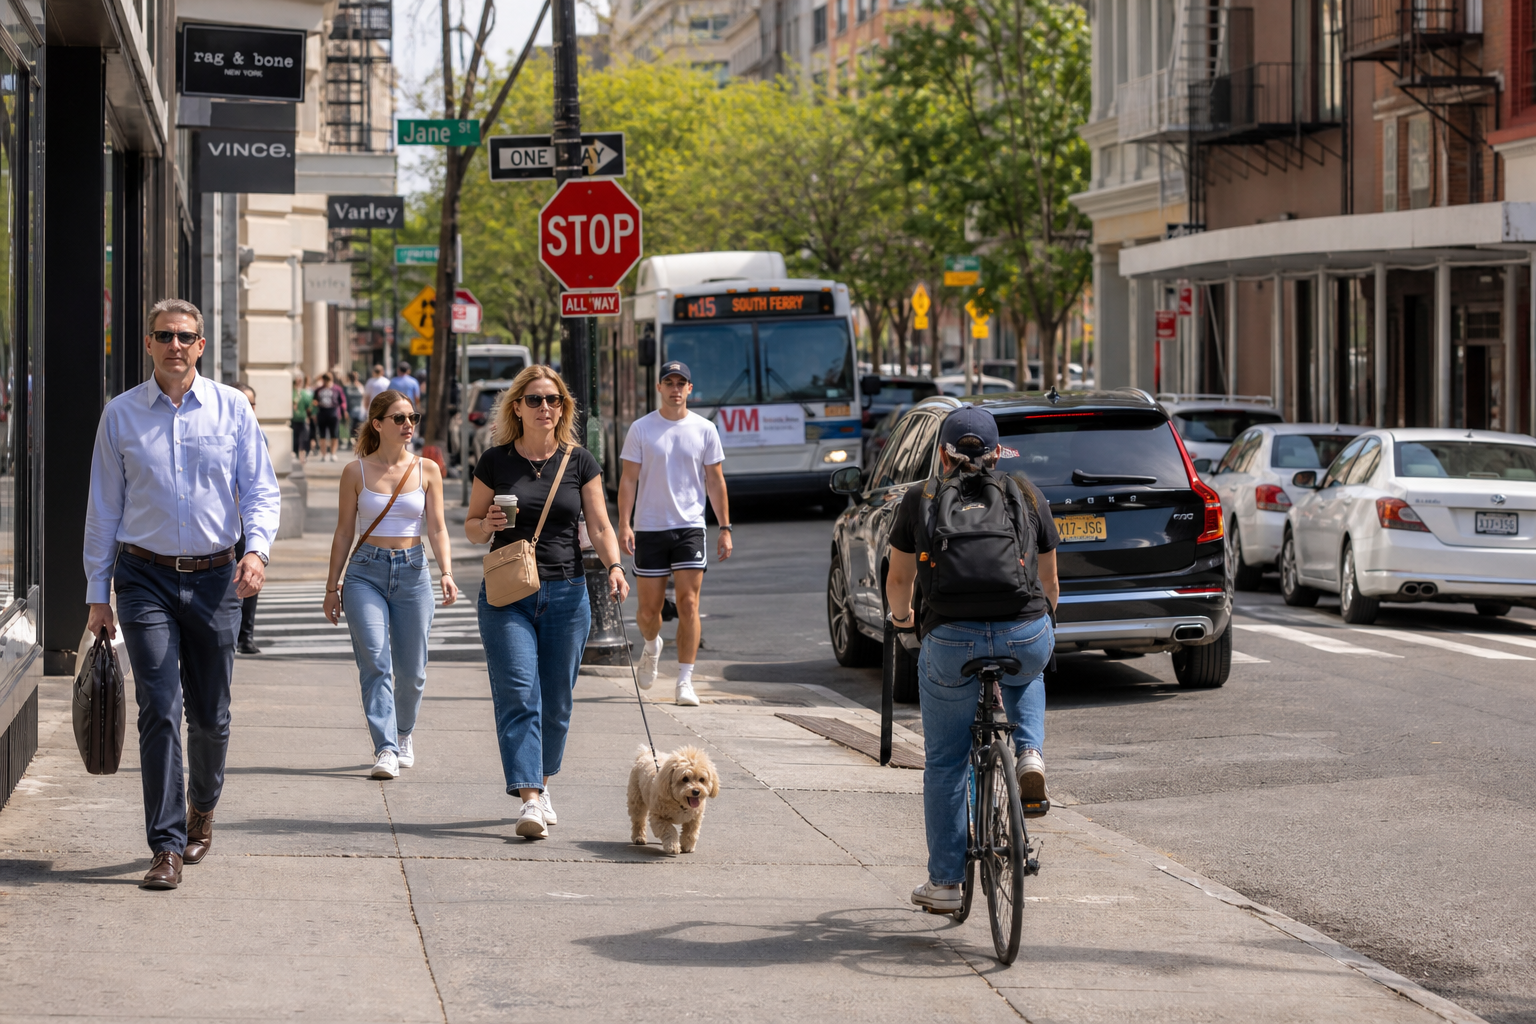

检测结果：images/results\street.jpg


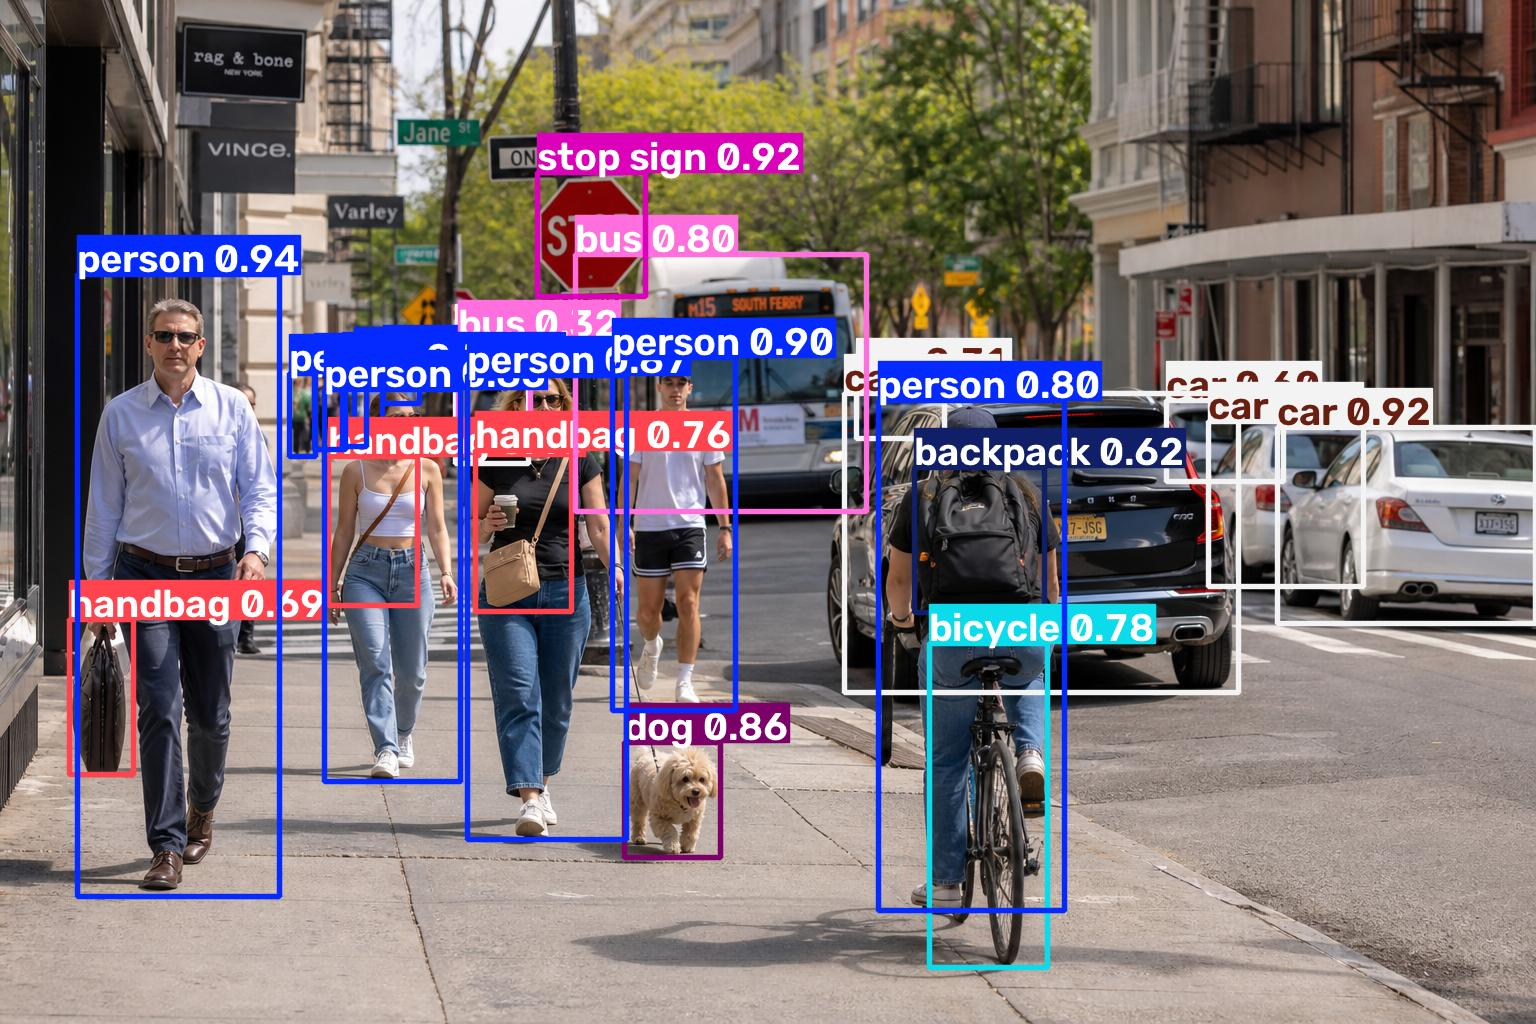

,xmin,ymin,xmax,ymax,confidence,class,name
0,77.926636,274.948669,279.410889,896.214355,0.935121,0,person
1,1277.951416,427.189880,1535.477051,623.002197,0.923132,2,car
2,537.124573,172.609268,645.186401,296.409088,0.921226,11,stop sign
3,612.648804,357.473145,735.508179,710.316772,0.896646,0,person
4,467.518494,375.089844,626.904236,839.283508,0.870068,0,person
5,624.517334,742.842651,720.671021,857.729187,0.860191,16,dog
6,1208.047852,421.199554,1363.876099,586.826965,0.857138,2,car
7,324.217957,389.992218,460.475525,781.300964,0.851428,0,person
8,878.116150,400.279602,1064.780640,910.200134,0.804810,0,person
9,575.754578,254.486526,866.015381,511.913910,0.802130,5,bus


In [4]:
# 待检测图片路径列表；类型：list[str]
# 也可传入：URL 字符串、PIL.Image 对象、numpy.ndarray（HWC 格式）
# 或上述类型的混合列表，AutoShape 内部统一处理
imgs = ['images/street.jpg']

# 将图片列表传入 AutoShape 模型进行端到端推理
# 内部流程：读取图片 → letterbox 缩放到 640×640 → 归一化到 [0,1]
#           → 前向传播 → NMS 非极大值抑制（过滤重叠预测框）
# 返回值类型：Detections 对象，封装所有图片的检测结果（支持链式访问）
results = model(imgs)

# 向标准输出打印每张图片的检测摘要
# 输出格式示例：image 1/1: 480x640 2 persons, 1 tie
# 返回值：None
results.print()

# 保存到 images/results/ 子目录，与原图所在的 images/ 目录隔离，避免覆盖原图
# exist_ok=True：目录已存在时不报错，返回 None
save_dir = 'images/results'
os.makedirs(save_dir, exist_ok=True)  # 返回 None；若 images/results/ 不存在则自动创建

# save_dir：str，指定结果图片的保存目录，覆盖默认的 runs/detect/exp/
# 保存文件名与输入图片同名（如 street.jpg → images/results/street.jpg）
# exist_ok=True：目录已存在时直接写入，不递增为 results2/results3/...（默认 False 会自动递增）
# 返回值：None
results.save(save_dir=save_dir, exist_ok=True)

# 先显示原图，便于与检测结果对比
# imgs: list[str]，每个元素为输入图片路径 str
for img_path in imgs:  # img_path: str，如 'images/street.jpg'
    print(f'原图：{img_path}')       # 打印原图路径标签，str
    display(Image(filename=img_path))  # 内联渲染原始图片到单元格输出

# results.files：list[str]，保存后各张结果图的文件名（不含目录）
# os.path.join 拼接目录与文件名，得到完整路径 str
# display(Image(...))：在当前 Notebook 单元格内联渲染检测结果图
for filename in results.files:  # filename: str，如 'street.jpg'
    saved_path = os.path.join(save_dir, filename)       # 完整路径，如 'images/results/street.jpg'
    print(f'检测结果：{saved_path}')                    # 打印结果图路径标签，str
    display(Image(filename=saved_path))                 # 渲染带检测框的结果图到单元格输出

# 访问第 0 张图片的预测框张量（索引对应 imgs 列表顺序）
# 返回值类型：torch.Tensor，shape=(N, 6)，N 为当前图片检测到的目标总数
# 每行格式：[x1, y1, x2, y2, confidence, class_id]
# 坐标单位：像素（原始图片分辨率），confidence ∈ [0, 1]，class_id: int（0~79）
results.xyxy[0]  # 仅赋值引用，不打印输出

# 将检测结果转换为 pandas.DataFrame，便于数据筛选与统计分析
# 返回值类型：pandas.DataFrame，shape=(N, 7)
# 列名：xmin, ymin, xmax, ymax, confidence, class, name
# class: int（类别 ID 0~79），name: str（类别名称，如 'person'、'tie'）
display(results.pandas().xyxy[0])

